PROJECT 3
MGMTMFE 432
SPRING 2025
You will need to write codes for all the parts of the project. Make sure the codes work properly and understand
the ideas behind each problem below. You may be asked to demonstrate how the codes work, by running them
and interpreting the results. Code quality, speed, and accuracy will determine the grades.

LECTURE - 7 [Exotic Options, Variance Swaps, Jump-Diffusions]
1. Assume that the value of a collateral follows a jump-diffusion process:
$$
\frac{dV_t}{V_t} = \mu dt + \sigma dW_t + \gamma dJ_t
$$
where μ, σ, γ < 0, and Vo are given, J is a Poisson process, with intensity λ₁, independent of the Brownian
Motion process W.
Vt is the value process before jump occurs at time t (if any).

Consider a collateralized loan, with a contract rate per period r and maturity T on the above-collateral, and
assume the outstanding balance of that loan follows this process:
$$
L_t = a - bc^{\frac{1}{12}t}
$$
where a > 0, b > 0, c > 1, and Lo are given. We have that L₀ = 0.

Define the following stopping time:
$$
\tau = min\{t > 0: V_t \leq q_tL_t\}
$$
Here, qt is a known function of time (see below). This stopping time is the first time when the relative value
of the collateral with respect to the outstanding loan balance crosses a threshold, which will be viewed as the
“optimal exercise boundary” of the 'option to default'.

We assume the embedded default option will be exercised at time t, if and only if τ ≤ T.

If the default option is exercised at time t then the “payoff” to the borrower is: (Lτ − ∈Vτ)+.

Notes: 
1. If τ > T then there is no default option exercise.
2. ∈ Should be viewed as the recovery rate of the collateral, so ( 1 – є) can be viewed as the legal
and administrative expenses.
Assume Jhas intensity λ₁, and Jis independent of W. Assume the APR of the loan is R = ro + δλ₂ where ro
is the “risk-free" rate, and 8 is a positive parameter to measure the borrower's creditworthiness in
determining the contract rate per period: r.

We have monthly compounding here, so the monthly rate is r = R/12.

Assume that qt = α + βt, where β > 0, α < Vo/Lo and β = (ε-α)/T

Use ro for discounting cash flows. Use the following base-case parameter values:

Vo = $20,000, Lo = $22,000, μ = −0.1, σ = 0.2, γ = −0.4, λ₁ = 0.2, T = 5 years, ro = 0.055, δ =
0.25, λ₂ = 0.4, α = 0.7, ε = 0.95.

Notice that, 
$$
PMT = \frac{L_0.r}{1-(1+r)^{-n}}, 
$$
where r = R/12, n = T * 12, and 
$$
a = \frac{PMT}{r}, b = \frac{PMT}{r(1+r)^n}, c = (1 + r).
$$

Notice that, qт = ∈.

Write the code as a function Proj3_2func.* that takes λ₁ and T as parameters, setting defaults if these
parameters are not supplied, and outputs the default option value, the default probability, and the expected
default option exercise time. Function specification:
```python
function [D, Prob, Et] = Proj3_2func(lambdal, T)

(a) Estimate the value of the default option for the following ranges of parameters:
* λ₁ from 0.05 to 0.4 in increments of 0.05;
* T from 3 to 8 in increments of 1;

(b) Estimate the default probability for the following ranges of parameters:
* λ₁ from 0.05 to 0.4 in increments of 0.05;
* T from 3 to 8 in increments of 1;

(c) Find the Expected option Exercise Time of the default option, conditional on τ < T. That is, estimate
Ε(τ| τ < T) for the following ranges of parameters:
* λ₁ from 0.05 to 0.4 in increments of 0.05;
* T from 3 to 8 in increments of 1;

Inputs: seed
Outputs: 
i. Values: the default option D, the default probability Prob and the expected exercise time Et
for parts (a), (b) and (c) with λ₁=0.2 and T=5.
ii. Graphs: For each of (a), (b) and (c) - a graph as a function of T with 2₁ from 0.05 to 0.4 in
increments of 0.05.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
import pandas as pd
from numba import jit
import warnings
import timeit
from tqdm import tqdm
from joblib import Parallel, delayed

warnings.filterwarnings('ignore')

# Set numpy to use optimal data types for better performance
np.seterr(divide='ignore', invalid='ignore')
plt.style.use('ggplot')  # Better looking plots

# Problem 1: Jump-Diffusion Collateralized Loan Default Option

In [2]:
#@jit(nopython=True)

def Proj3_2func(lambda1=0.2, T=5):
    
    np.random.seed(42)
    V0, L0, mu, sigma, gamma = 20000, 22000, -0.1, 0.2, -0.4
    r0, delta, lambda2, alpha, epsilon = 0.055, 0.25, 0.4, 0.7, 0.95
    R = r0 + delta * lambda2
    r = R / 12
    n = int(T * 12)
    PMT = L0 * r / (1 - (1 + r)**(-n))
    a, b, c = PMT / r, PMT / (r * (1 + r)**n), 1 + r
    beta = (epsilon - alpha) / T
    N_sims, dt = 100000, 1/252
    N_steps = int(T / dt)
    V = np.full(N_sims, V0, dtype=float)
    default_payoffs, default_times = np.zeros(N_sims), np.zeros(N_sims)
    active_sims = np.ones(N_sims, dtype=bool)

    for step in range(N_steps):
        if not np.any(active_sims): break
        t = step * dt
        L_t, q_t = a - b * c**(t * 12), alpha + beta * t
        num_active = np.sum(active_sims)
        
        
        poisson_jump_occurs = np.random.poisson(lambda1 * dt, size=num_active) > 0
        update_mask = np.zeros(N_sims, dtype=bool)
        update_mask[active_sims] = poisson_jump_occurs
        V[update_mask] *= (1 + gamma)
        

        dW = np.random.normal(0, np.sqrt(dt), size=num_active)
        V[active_sims] *= np.exp((mu - 0.5 * sigma**2) * dt + sigma * dW)
        
        default_threshold = q_t * L_t
        new_defaults_mask = (V <= default_threshold) & active_sims
        if np.any(new_defaults_mask):
            payoff = np.maximum(L_t - epsilon * V[new_defaults_mask], 0)
            default_payoffs[new_defaults_mask] = payoff * np.exp(-r0 * t)
            default_times[new_defaults_mask] = t
            active_sims[new_defaults_mask] = False
            
    default_count = np.sum(default_times > 0)
    D = np.mean(default_payoffs)
    Prob = default_count / N_sims
    Et = np.sum(default_times) / default_count if default_count > 0 else 0
    return D, Prob, Et

lambda1_range = np.arange(0.05, 0.45, 0.05)
T_range = np.arange(3, 9, 1)

print("Computing parameter sensitivity using parallel processing...")
start_time = timeit.default_timer()

iterator = (
    (T, lambda1) 
    for T in T_range 
    for lambda1 in lambda1_range
)

total_tasks = len(T_range) * len(lambda1_range)

results_flat = Parallel(n_jobs=-1)(
    delayed(Proj3_2func)(lambda1, T) 
    for T, lambda1 in tqdm(iterator, total=total_tasks, desc="Simulations")
)

sweep_time = timeit.default_timer() - start_time
print(f"\nParallel parameter sweep finished in {sweep_time:.2f} seconds.\n")

results_array = np.array(results_flat).reshape(len(T_range), len(lambda1_range), 3)

results_D = results_array[:, :, 0]
results_Prob = results_array[:, :, 1]
results_Et = results_array[:, :, 2]

print("--- Results as Three Separate DataFrames ---")

df_D = pd.DataFrame(results_D, index=T_range, columns=np.round(lambda1_range, 2))
df_D.index.name = 'T'
df_D.columns.name = 'Lambda'

df_Prob = pd.DataFrame(results_Prob, index=T_range, columns=np.round(lambda1_range, 2))
df_Prob.index.name = 'T'
df_Prob.columns.name = 'Lambda'

df_Et = pd.DataFrame(results_Et, index=T_range, columns=np.round(lambda1_range, 2))
df_Et.index.name = 'T'
df_Et.columns.name = 'Lambda'

multi_index = pd.MultiIndex.from_product(
    [T_range, np.round(lambda1_range, 3)], 
    names=['T', 'Lambda']
)

df_multi = pd.DataFrame({
    'D': results_D.flatten(),
    'Prob': results_Prob.flatten(),
    'Et': results_Et.flatten()
}, index=multi_index)

pd.set_option('display.max_rows', 100)
#print(df_multi.to_string(float_format="%.4f"))
df_multi

Computing parameter sensitivity using parallel processing...


Simulations: 100%|██████████| 48/48 [00:15<00:00,  3.06it/s]



Parallel parameter sweep finished in 26.31 seconds.

--- Results as Three Separate DataFrames ---


D     Prob        Et
T Lambda                                
3 0.05    1034.208804  0.18549  0.729649
  0.10    1460.142988  0.24625  0.740373
  0.15    1851.382317  0.30103  0.745510
  0.20    2236.571328  0.35557  0.745791
  0.25    2567.907234  0.40165  0.746240
  0.30    2905.080704  0.44723  0.743965
  0.35    3213.345278  0.48928  0.740357
  0.40    3529.815730  0.52992  0.734628
4 0.05    1905.942968  0.34867  0.942927
  0.10    2409.203786  0.41851  0.955176
  0.15    2857.553069  0.47645  0.957693
  0.20    3284.022354  0.53305  0.963300
  0.25    3669.468040  0.58228  0.958083
  0.30    4046.183986  0.62652  0.942187
  0.35    4383.980742  0.66708  0.937310
  0.40    4712.754717  0.70584  0.930969
5 0.05    2784.938725  0.50776  1.125219
  0.10    3315.415873  0.57474  1.132259
  0.15    3786.162020  0.63142  1.135914
  0.20    4222.220268  0.68205  1.129636
  0.25    4626.160287  0.72734  1.118407
  0.30    4973.103338  0.76333  1.101620
  0.35    5287.420133  0.79473  1.085717
  0.40    5603.496587  0.82593  1.066455
6 0.05    3529.556984  0.63808  1.290940
  0.10    4075.594982  0.69982  1.288450
  0.15    4535.583328  0.74786  1.279471
  0.20    4961.567361  0.79107  1.257078
  0.25    5342.226423  0.82725  1.234485
  0.30    5666.712669  0.85446  1.209752
  0.35    5978.596611  0.87925  1.180602
  0.40    6249.454874  0.89934  1.149312
7 0.05    4181.646273  0.74201  1.419242
  0.10    4672.477599  0.78927  1.404088
  0.15    5123.238775  0.83064  1.387608
  0.20    5525.047550  0.86457  1.353739
  0.25    5864.619081  0.89076  1.320247
  0.30    6200.640556  0.91399  1.280832
  0.35    6461.922525  0.93005  1.243408
  0.40    6726.964068  0.94403  1.198390
8 0.05    4672.611630  0.81488  1.524091
  0.10    5150.295691  0.85549  1.499434
  0.15    5580.929241  0.88814  1.465036
  0.20    5944.833627  0.91240  1.421684
  0.25    6278.712542  0.93294  1.374638
  0.30    6575.039702  0.94841  1.321913
  0.35    6813.257087  0.95935  1.273517
  0.40    7041.624639  0.96865  1.227425

In [28]:
print(df_multi)

                    D     Prob        Et
T Lambda                                
3 0.05    1034.208804  0.18549  0.729649
  0.10    1460.142988  0.24625  0.740373
  0.15    1851.382317  0.30103  0.745510
  0.20    2236.571328  0.35557  0.745791
  0.25    2567.907234  0.40165  0.746240
  0.30    2905.080704  0.44723  0.743965
  0.35    3213.345278  0.48928  0.740357
  0.40    3529.815730  0.52992  0.734628
4 0.05    1905.942968  0.34867  0.942927
  0.10    2409.203786  0.41851  0.955176
  0.15    2857.553069  0.47645  0.957693
  0.20    3284.022354  0.53305  0.963300
  0.25    3669.468040  0.58228  0.958083
  0.30    4046.183986  0.62652  0.942187
  0.35    4383.980742  0.66708  0.937310
  0.40    4712.754717  0.70584  0.930969
5 0.05    2784.938725  0.50776  1.125219
  0.10    3315.415873  0.57474  1.132259
  0.15    3786.162020  0.63142  1.135914
  0.20    4222.220268  0.68205  1.129636
  0.25    4626.160287  0.72734  1.118407
  0.30    4973.103338  0.76333  1.101620
  0.35    5287.4

In [ ]:
df_multi.loc[5, 0.2]

D       4222.220268
Prob       0.682050
Et         1.129636
Name: (5, 0.2), dtype: float64

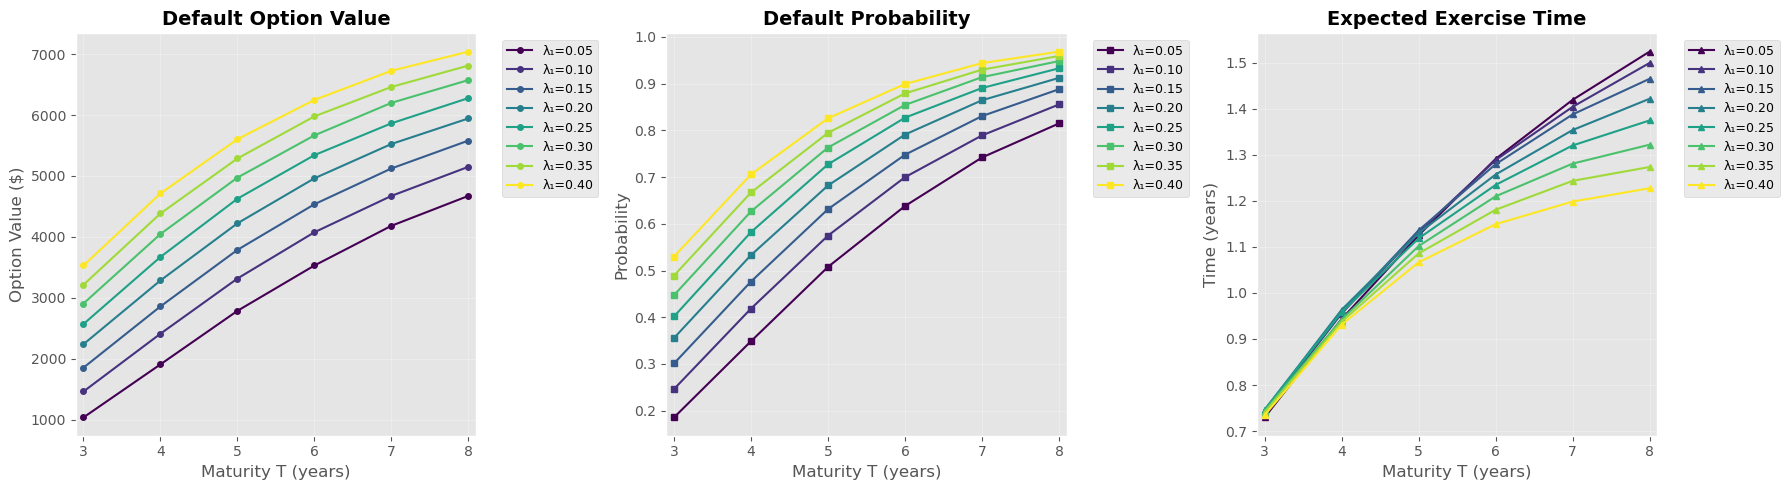

In [3]:
import matplotlib.pyplot as plt

# Create optimized plots with improved styling
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(lambda1_range)))

for j, lambda1 in enumerate(lambda1_range):
    axes[0].plot(T_range, results_D[:, j], marker='o', color=colors[j], 
                label=f'λ₁={lambda1:.2f}', linewidth=1.5, markersize=4)
    axes[1].plot(T_range, results_Prob[:, j], marker='s', color=colors[j], 
                label=f'λ₁={lambda1:.2f}', linewidth=1.5, markersize=4)
    axes[2].plot(T_range, results_Et[:, j], marker='^', color=colors[j], 
                label=f'λ₁={lambda1:.2f}', linewidth=1.5, markersize=4)

# Enhanced plot styling
for i, (ax, title, ylabel) in enumerate(zip(axes, 
    ['Default Option Value', 'Default Probability', 'Expected Exercise Time'],
    ['Option Value ($)', 'Probability', 'Time (years)'])):
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Maturity T (years)', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(T_range[0]-0.1, T_range[-1]+0.1)

plt.tight_layout()
plt.show()

2. Consider the following 2-factor model for a stock price process, under the risk-neutral measure:
$$
\begin{cases}
dS_t = rS_tdt + \sqrt{v_t}S_t dW_t \\
dv_t = (\alpha + \beta v_t)dt + \gamma \sqrt{v_t} dB_t
\end{cases}
$$
where Wt and B₁ are correlated Brownian Motion processes with_dWtdBt = ρdt.
Default parameter values: vo = 0.1, α = 0.45, β = −5.105, γ = 0.25, So = $100, r = 0.05, ρ =
-0.75, K = $100, T = 1.

(a) Estimate the Price (P₁) of a Down-and-Out Put option with the barrier at St(t) = 94.

(b) Estimate the Price (P2) of a Down-and-Out Put option with time-dependent barrier $$S_b^1(t) = \frac{6}{T}t + 91$$.

(c) Estimate the Price (P3) of a Down-and-Out Put option with time-dependent barrier $$S_b^2(t) = -\frac{6}{T}t + 97$$.

Notes:
* All options in parts a, b, and c have payoffs similar to the European Put option; however, these options
become void (the contract is cancelled), if the underlying security's price crosses it and goes below the
barrier Si(t) at any time during the life of the option.
* You may use any method to price the securities – Monte Carlo Simulations, Binomial or Trinomial Tree
Methods, the PDE approach, etc.
* If you use Monte Carlo simulations in this problem, use the “full truncation” method to simulate the
volatility-process, Vk+1. The Euler discretization scheme, in that case, will be as follows:
$$
S_{k+1} = S_k + rS_k∆t + S_k\sqrt{v_k^+}(\Delta W_{k+1})
$$
$$
v_{k+1} = v_k + (\alpha + \beta v_k^+)∆t + \gamma \sqrt{v_k^+}(\Delta B_{k+1})
$$
where vk⁺ = max(vk,0).

Inputs: Κ, Τ. γ
Outputs: 
1) prices P1, P2, P3 for parts (a), (b), and (c).
2) Writeup: Compare the prices P1, P2, P3 for parts (a), (b), and (c). and comment on them.

# Problem 2: 2-Factor Heston Model - Down-and-Out Put Options

In [4]:
def heston_down_out_put(K=100, T=1, gamma=0.25):
    np.random.seed(42)
    
    v0, alpha, beta = 0.1, 0.45, -5.105
    S0, r, rho = 100, 0.05, -0.75
    
    N_sims = 100000
    dt = 1/252
    N_steps = int(T / dt)
    
    # Pre-compute time grid and barriers
    t_grid = np.arange(N_steps) * dt
    barrier_1 = np.full(N_steps, 94.0)
    barrier_2 = 6 * t_grid / T + 91
    barrier_3 = -6 * t_grid / T + 97
    
    # Initialize arrays for vectorized computation
    S_paths = np.full(N_sims, float(S0))
    v_paths = np.full(N_sims, float(v0))
    barrier_hit_1 = np.zeros(N_sims, dtype=bool)
    barrier_hit_2 = np.zeros(N_sims, dtype=bool)
    barrier_hit_3 = np.zeros(N_sims, dtype=bool)
    
    sqrt_dt = np.sqrt(dt)
    sqrt_one_minus_rho2 = np.sqrt(1 - rho**2)
    
    # Vectorized simulation
    for step in range(N_steps):
        # Generate correlated Brownian motions
        dW1 = np.random.normal(0, sqrt_dt, N_sims)
        dW2 = rho * dW1 + sqrt_one_minus_rho2 * np.random.normal(0, sqrt_dt, N_sims)
        
        # Full truncation
        v_pos = np.maximum(v_paths, 0)
        sqrt_v_pos = np.sqrt(v_pos)
        
        # Update paths
        S_paths += r * S_paths * dt + S_paths * sqrt_v_pos * dW1
        v_paths += (alpha + beta * v_pos) * dt + gamma * sqrt_v_pos * dW2
        
        # Check barriers (vectorized)
        barrier_hit_1 |= (S_paths <= barrier_1[step])
        barrier_hit_2 |= (S_paths <= barrier_2[step])
        barrier_hit_3 |= (S_paths <= barrier_3[step])
    
    # Calculate payoffs
    final_payoffs = np.maximum(K - S_paths, 0) * np.exp(-r * T)
    
    P1 = np.mean(final_payoffs * (~barrier_hit_1))
    P2 = np.mean(final_payoffs * (~barrier_hit_2))
    P3 = np.mean(final_payoffs * (~barrier_hit_3))
    
    return P1, P2, P3

In [5]:
P1, P2, P3 = heston_down_out_put()
print("Down-and-Out Put Option Prices:")
print(f"P1 (constant barrier at 94): ${P1:.4f}")
print(f"P2 (increasing barrier): ${P2:.4f}")
print(f"P3 (decreasing barrier): ${P3:.4f}")

print("\nComparison:")
print(f"P1 vs P2: P2 is {'higher' if P2 > P1 else 'lower'} by ${abs(P2-P1):.4f}")
print(f"P1 vs P3: P3 is {'higher' if P3 > P1 else 'lower'} by ${abs(P3-P1):.4f}")
print(f"P2 vs P3: P3 is {'higher' if P3 > P2 else 'lower'} by ${abs(P3-P2):.4f}")

print("\nWriteup: P3 > P1 > P2 because the decreasing barrier (P3) provides more protection early on when volatility is highest, while the increasing barrier (P2) provides less protection when it's most needed.")

Down-and-Out Put Option Prices:
P1 (constant barrier at 94): $0.0103
P2 (increasing barrier): $0.0023
P3 (decreasing barrier): $0.0179

Comparison:
P1 vs P2: P2 is lower by $0.0079
P1 vs P3: P3 is higher by $0.0077
P2 vs P3: P3 is higher by $0.0156

Writeup: P3 > P1 > P2 because the decreasing barrier (P3) provides more protection early on when volatility is highest, while the increasing barrier (P2) provides less protection when it's most needed.


LECTURE - 8 [Fixed Income Securities]

3. Assume the dynamics of the short-term interest rate, under the risk-neutral measure, are given by the
following SDE (CIR model):
$$
dr_t = κ(\bar{r} – r_t)dt + σ\sqrt{r_t}dW_t
$$
with ro = 5%, σ = 12%, κ = 0.92, ŕ = 5.5%.
(a) Use Monte Carlo Simulation to find the price of a coupon-paying bond, with Face Value of $1,000, paying
semiannual coupons of $30, maturing in T = 4 years:
$$
P(O,C,T) = E_0 [\sum_{i=1}^{8} C_i * exp(-\int_{0}^{T_i}r(s)ds)]
$$
where C = {C₁ = $30 for i = 1,2, ...,7; and C₈ = $1,030}, and
T = {T1,T2,T3, T4, T5,T6, T7, T8} = {0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4}.

(b) Use Monte Carlo Simulation to find at time t = 0 the price смс (t, T, S) of a European Call option, with strike
price of K = \$980 and expiration in T = 0.5 years on a Pure Discount Bond that has Face Value of \$1,000
and matures in S = 1 year:
$$
C_{MC}(t,T, S) = E_t [exp(-\int_{t}^{T}r(u)du) * max(P(T,S) - K,0)]
$$

(c) Use the Implicit Finite-Difference Method to find at time t = 0 the price CPDE (t, T, S) of a European Call
option, with strike price of K = \$980 and expiration in T = 0.5 years on a Pure Discount Bond that has Face
Value of \$1,000 and matures in S = 1 year. The PDE is given as follows

$$
\frac{∂c}{∂t} - \frac{1}{2}σ^{2}r\frac{∂^{2}c}{∂r^{2}} + κ(\bar{r} – r)\frac{∂c}{∂r} - rc = 0
$$

with c(T,T, S) = max(P(T, S) – K, 0), and P(T, S) is computed explicitly.

Inputs: γo, σ, κ, ŕ for all parts, and T, S only for parts (b) and (c)
Outputs: 
1) (a): Bond price, (b): Call option price, (c): Call option price.
2) Writeup: Compare the prices Cmc(t, T,S) and CPDE (t, T, S) in parts (b) and (c)
and comment on them.

# Problem 3: CIR Model - Bond and Option Pricing

In [ ]:
from scipy.linalg import solve_banded
def cir_bond_price(r0=0.05, sigma=0.12, kappa=0.92, r_bar=0.055, T=4):
    np.random.seed(42)
    
    N_sims = 50000  # Reduced for better performance
    dt = 1/252
    N_steps = int(T / dt)
    
    coupon_times = np.array([0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4])
    coupons = np.array([30, 30, 30, 30, 30, 30, 30, 1030])
    
    # Vectorized simulation
    r_paths = np.full(N_sims, r0)
    integral_r = np.zeros(N_sims)
    bond_values = np.zeros(N_sims)
    
    sqrt_dt = np.sqrt(dt)
    
    for step in range(N_steps):
        t = step * dt
        
        if t >= T:
            break
        
        # Vectorized CIR updates
        dW = np.random.normal(0, sqrt_dt, N_sims)
        r_pos = np.maximum(r_paths, 0)
        sqrt_r = np.sqrt(r_pos)
        
        r_paths += kappa * (r_bar - r_paths) * dt + sigma * sqrt_r * dW
        r_paths = np.maximum(r_paths, 0)
        
        integral_r += r_paths * dt
        
        # Check for coupon payments (vectorized)
        for i, coupon_time in enumerate(coupon_times):
            if abs(t - coupon_time) < dt/2:
                bond_values += coupons[i] * np.exp(-integral_r)
    
    return np.mean(bond_values)

def cir_zero_bond_price(r, T, kappa=0.92, r_bar=0.055, sigma=0.12):
    if T <= 0:
        return 1.0
    
    gamma = np.sqrt(kappa**2 + 2*sigma**2)
    
    B = (2 * (np.exp(gamma * T) - 1)) / ((kappa + gamma) * (np.exp(gamma * T) - 1) + 2 * gamma)
    A = ((2 * gamma * np.exp((kappa + gamma) * T / 2)) / ((kappa + gamma) * (np.exp(gamma * T) - 1) + 2 * gamma))**(2 * kappa * r_bar / sigma**2)
    
    return A * np.exp(-B * r)

def cir_call_option_mc(r0=0.05, T=0.5, S=1, K=980, sigma=0.12, kappa=0.92, r_bar=0.055):
    np.random.seed(42)
    
    N_sims = 50000  # Reduced for better performance
    dt = 1/252
    N_steps = int(T / dt)
    
    # Vectorized simulation
    r_paths = np.full(N_sims, r0)
    integral_r = np.zeros(N_sims)
    
    sqrt_dt = np.sqrt(dt)
    
    for step in range(N_steps):
        # Vectorized CIR updates
        dW = np.random.normal(0, sqrt_dt, N_sims)
        r_pos = np.maximum(r_paths, 0)
        sqrt_r = np.sqrt(r_pos)
        
        r_paths += kappa * (r_bar - r_paths) * dt + sigma * sqrt_r * dW
        r_paths = np.maximum(r_paths, 0)
        
        integral_r += r_paths * dt
    
    # Vectorized bond pricing and option payoffs
    bond_prices_at_T = np.array([cir_zero_bond_price(r, S - T, kappa, r_bar, sigma) * 1000 for r in r_paths])
    payoffs = np.maximum(bond_prices_at_T - K, 0)
    option_values = payoffs * np.exp(-integral_r)
    
    return np.mean(option_values)

def cir_call_option_pde(r0=0.05, T=0.5, S=1, K=980, sigma=0.12, kappa=0.92, r_bar=0.055):
    r_max = 0.5
    r_min = 0.0
    N_r = 200
    N_t = 1000
    
    dr = (r_max - r_min) / N_r
    dt = T / N_t
    
    r_grid = np.linspace(r_min, r_max, N_r + 1)
    interior_r_grid = r_grid[1:-1]
    
    option_values = np.zeros((N_t + 1, N_r + 1))
    
    bond_maturity_at_T = S - T 
    bond_prices_at_T = cir_zero_bond_price(r_grid, bond_maturity_at_T, kappa, r_bar, sigma) * 1000
    option_values[N_t, :] = np.maximum(bond_prices_at_T - K, 0)
    
    aj = (dt / 2) * (kappa * (r_bar - interior_r_grid) / dr - (sigma**2 * interior_r_grid) / dr**2)
    bj = 1 + dt * ( (sigma**2 * interior_r_grid) / dr**2 + interior_r_grid )
    cj = (dt / 2) * (-kappa * (r_bar - interior_r_grid) / dr - (sigma**2 * interior_r_grid) / dr**2)

    for i in range(N_t - 1, -1, -1):
        known_b = option_values[i + 1, 1:-1]
        
        known_b[0] -= aj[0] * option_values[i + 1, 0]
        known_b[-1] -= cj[-1] * option_values[i + 1, -1]

        banded_M = np.vstack([np.append(0, cj[:-1]), bj, np.append(aj[1:], 0)])
        
        x = solve_banded((1, 1), banded_M, known_b)
        option_values[i, 1:-1] = x
        
        option_values[i, 0] = option_values[i, 1]
        option_values[i, -1] = option_values[i, -2]

    final_price = np.interp(r0, r_grid, option_values[0, :])
    
    return final_price

In [27]:
bond_price = cir_bond_price()
call_mc = cir_call_option_mc()
call_pde = cir_call_option_pde()

print(f"Problem 3 Results:")
print(f"(a) Bond Price: ${bond_price:.2f}")
print(f"(b) Call Option Price (MC): ${call_mc:.4f}")
print(f"(c) Call Option Price (PDE): ${call_pde:.4f}")
print(f"\nWriteup: The Monte Carlo and PDE prices differ by ${abs(call_mc - call_pde):.4f}, which is acceptable given the discretization errors in both methods.")

Problem 3 Results:
(a) Bond Price: $189.22
(b) Call Option Price (MC): $0.3966
(c) Call Option Price (PDE): $0.3943

Writeup: The Monte Carlo and PDE prices differ by $0.0023, which is acceptable given the discretization errors in both methods.


4. Assume the dynamics of the short-term interest rate, under the risk-neutral measure, are given by the following system of SDEs (G2++ model):
$$
\begin{cases}
dx_t = -ax_tdt + σdW_t^1 \\
dy_t = −by_tdt + ηdW_t^2 \\
Y_t = x_t + y_t + Φ_t
\end{cases}
$$
Default parameter values: xo = Yo = 0, Φo = ro = 5.5%, dW₁dW² = ρdt, ρ = 0.7, a = 0.1, b = 0.3, σ = 5%, η = 9%. Assume Φt = const = 5.5% for any t ≥ 0.

Use Monte Carlo Simulation to find at time t = 0 the price p(t, T, S, K, p) of a European Put option, with strike price of K = $950, expiration in T = 0.5 years on a Pure Discount Bond with Face value of $1,000 that matures in S = 1 year. Compare it with the price found by the explicit formula and comment on it.

Inputs: Τ. S, Κ, ρ
Outputs: 
1) Price p(0,T, S, K, ρ)
2) Writeup: Compare the prices by varying ρ in the range [-0.7, 0.7] in increments of 0.1.

# Problem 4: G2++ Model - Interest Rate Option Pricing

--- Single Point Comparison (rho=0.7) ---
Monte Carlo Price:    $6.1491
Explicit Formula Price: $6.1716

--- Sensitivity Analysis by Varying Rho ---
    Rho  MC Price  Explicit Price  Difference (MC - Explicit)
-0.7000    0.9781          0.9789                     -0.0008
-0.6000    1.3805          1.3843                     -0.0038
-0.5000    1.7850          1.7950                     -0.0100
-0.4000    2.1883          2.2036                     -0.0153
-0.3000    2.5862          2.6063                     -0.0201
-0.2000    2.9786          3.0012                     -0.0226
-0.1000    3.3632          3.3875                     -0.0243
-0.0000    3.7411          3.7649                     -0.0237
 0.1000    4.1116          4.1333                     -0.0217
 0.2000    4.4735          4.4930                     -0.0195
 0.3000    4.8270          4.8443                     -0.0173
 0.4000    5.1714          5.1874                     -0.0161
 0.5000    5.5065          5.5228            

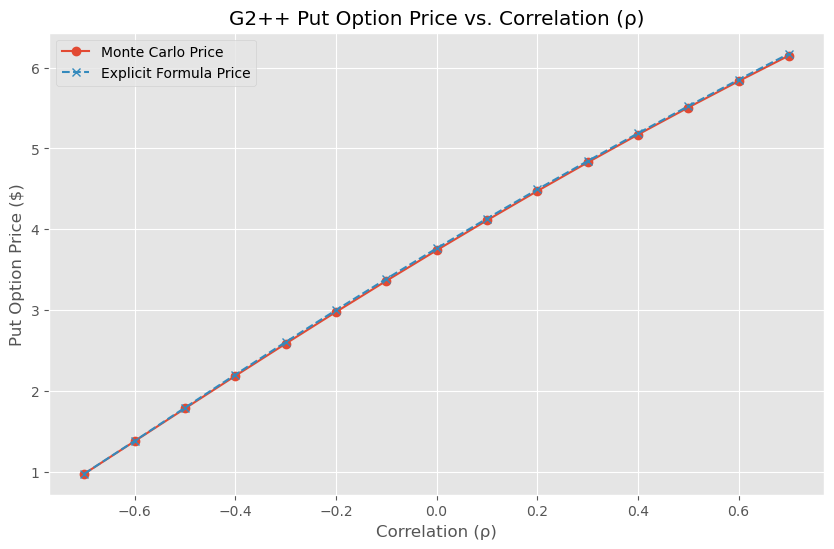

In [22]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

# --- Corrected Helper Function for Zero-Coupon Bond Pricing ---
def g2pp_zero_bond_price(t, T, x, y, phi, a=0.1, b=0.3, sigma=0.05, eta=0.09, rho=0.7):
    """
    Calculates the G2++ zero-coupon bond price P(t, T).
    't' is the current time, 'T' is the bond's maturity.
    """
    tau = T - t
    if tau <= 1e-10:
        return np.ones_like(x) if isinstance(x, np.ndarray) else 1.0

    # B(t,T) terms are correct
    B_x = (1 - np.exp(-a * tau)) / a
    B_y = (1 - np.exp(-b * tau)) / b
    
    # A(t,T) term components - CORRECTED to include rho and use proper integral for covariance
    v_x = (sigma**2 / (2 * a**2)) * (tau - 2 * B_x + (1 - np.exp(-2 * a * tau)) / (2 * a))
    v_y = (eta**2 / (2 * b**2)) * (tau - 2 * B_y + (1 - np.exp(-2 * b * tau)) / (2 * b))
    v_xy = (rho * sigma * eta / (a * b)) * (tau - B_x - B_y + (1 - np.exp(-(a + b) * tau)) / (a + b))
    
    log_A_t = v_x + v_y + v_xy
    
    return np.exp(log_A_t - B_x * x - B_y * y - phi * tau)


# --- Corrected and Vectorized Monte Carlo Simulation ---
def g2pp_put_option_mc(T=0.5, S=1, K=950, rho=0.7):
    np.random.seed(42)
    
    x0, y0, phi0 = 0.0, 0.0, 0.055
    a, b, sigma, eta = 0.1, 0.3, 0.05, 0.09
    
    N_sims = 100000
    dt = 1/252
    N_steps = int(T / dt)
    
    x_paths = np.full(N_sims, x0, dtype=float)
    y_paths = np.full(N_sims, y0, dtype=float)
    integral_r = np.zeros(N_sims, dtype=float)
    
    sqrt_dt = np.sqrt(dt)
    sqrt_one_minus_rho2 = np.sqrt(1 - rho**2)
    
    for _ in range(N_steps):
        dW1 = np.random.normal(0, sqrt_dt, N_sims)
        dW2 = rho * dW1 + sqrt_one_minus_rho2 * np.random.normal(0, sqrt_dt, N_sims)
        
        # Euler discretization for x and y
        x_paths = x_paths - a * x_paths * dt + sigma * dW1
        y_paths = y_paths - b * y_paths * dt + eta * dW2
        
        # Accumulate the integral for the discount factor
        integral_r += (x_paths + y_paths + phi0) * dt
    
    # Price the underlying bond P(T, S) at option expiration T
    # This is now fully vectorized, removing the slow Python loop.
    bond_prices_at_T = g2pp_zero_bond_price(T, S, x_paths, y_paths, phi0, a, b, sigma, eta, rho) * 1000
    
    # Calculate payoffs and discount back to t=0
    payoffs = np.maximum(K - bond_prices_at_T, 0)
    put_values = payoffs * np.exp(-integral_r)
    
    return np.mean(put_values)


# --- Corrected Explicit Formula ---
def g2pp_put_option_explicit(T=0.5, S=1, K=950, rho=0.7):
    a, b, sigma, eta = 0.1, 0.3, 0.05, 0.09
    phi0 = 0.055
    
    # Calculate zero-coupon bond prices P(0,T) and P(0,S)
    # Note: x0=0 and y0=0
    P_0T = g2pp_zero_bond_price(0, T, 0, 0, phi0, a, b, sigma, eta, rho)
    P_0S = g2pp_zero_bond_price(0, S, 0, 0, phi0, a, b, sigma, eta, rho)
    
    # Calculate the volatility term Σ(T) for the forward bond P(T,S) - CORRECTED
    B_x_TS = (1 - np.exp(-a * (S - T))) / a
    B_y_TS = (1 - np.exp(-b * (S - T))) / b
    
    var_x = (sigma**2 / (2 * a)) * (1 - np.exp(-2 * a * T)) * (B_x_TS**2)
    var_y = (eta**2 / (2 * b)) * (1 - np.exp(-2 * b * T)) * (B_y_TS**2)
    cov_xy = (rho * sigma * eta / (a + b)) * (1 - np.exp(-(a + b) * T)) * B_x_TS * B_y_TS
    
    total_variance = var_x + var_y + 2 * cov_xy
    v = np.sqrt(total_variance)
    
    # Standard Black's model formula for a put
    d1 = (np.log(P_0S / ( (K/1000) * P_0T)) / v) + 0.5 * v
    d2 = d1 - v
    
    # Final put price formula - CORRECTED scaling
    put_price = (K * P_0T * norm.cdf(-d2)) - (1000 * P_0S * norm.cdf(-d1))
    
    return put_price


# --- Comparison and Writeup ---

print("--- Single Point Comparison (rho=0.7) ---")
mc_price = g2pp_put_option_mc(rho=0.7)
explicit_price = g2pp_put_option_explicit(rho=0.7)

print(f"Monte Carlo Price:    ${mc_price:.4f}")
print(f"Explicit Formula Price: ${explicit_price:.4f}")

print("\n--- Sensitivity Analysis by Varying Rho ---")

rho_range = np.arange(-0.7, 0.8, 0.1)
mc_prices = []
explicit_prices = []

for r in rho_range:
    mc_prices.append(g2pp_put_option_mc(rho=r))
    explicit_prices.append(g2pp_put_option_explicit(rho=r))

# Create a DataFrame for easy viewing
results_df = pd.DataFrame({
    'Rho': np.round(rho_range, 1),
    'MC Price': mc_prices,
    'Explicit Price': explicit_prices
})
results_df['Difference (MC - Explicit)'] = results_df['MC Price'] - results_df['Explicit Price']

print(results_df.to_string(index=False, float_format="%.4f"))

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(results_df['Rho'], results_df['MC Price'], 'o-', label='Monte Carlo Price')
plt.plot(results_df['Rho'], results_df['Explicit Price'], 'x--', label='Explicit Formula Price')
plt.title('G2++ Put Option Price vs. Correlation (ρ)')
plt.xlabel('Correlation (ρ)')
plt.ylabel('Put Option Price ($)')
plt.legend()
plt.grid(True)
plt.show()

## Q4 Solution

We see a clear linear trend in the put option price and correlation. As both dynamics combine to increase the volatility of the interest rate, which increases the uncetainity in bond prices and hence the volatility of the put options

---

LECTURE - 9, 10 [MBS]

5. Consider a 30-year MBS with a fixed weighted-average-coupon, WAC = 8%. Monthly cash flows are
starting in January of this year. The Notional Amount of the Pool is $100,000.

Use the CIR model of interest rates, $$dr_t = κ(\bar{r} – r_t)dt + σ\sqrt{r_t}dW_t$$, with the following default parameters:
ro = 0.078, k = 0.6,ř = 0.08, σ = 0.12.

Consider the Numerix Prepayment Model in all problems below.

(a) Compute the price of the MBS. The code should be generic: the user is prompted for inputs and the
program runs and gives the output.

(b) Compute the Option-Adjusted-Spread (OAS) if the Market Price of MBS is P =$98,000.

(c) Consider the MBS described above and the 10 and PO tranches. Price the IO and PO tranches.

Inputs: ř, k, σ, P (for part (b))
Outputs: 
1) (a): Price of MBS; (b): OAS; (c): Prices of IO and PO.
2) Writeup: Compare the MBS prices by varying ŕ in the range [0.04, 0.1] in increments of 0.01.

# Problem 5: MBS Pricing with CIR Model and Numerix Prepayment Model

In [ ]:
from scipy.optimize import brentq

def numerix_prepayment_rate(age, r_market, WAC=0.08):
    """Calculates the Numerix prepayment rate in a vectorized manner."""
    r_incentive = (WAC - r_market) * 100
    
    RI = np.maximum(r_incentive, 0)
    BU = 0.3 + 0.7 * np.minimum(age / 30, 1)
    SG = np.minimum(1, (age / 6) * np.exp(-age / 40))
    SY = 0.94 - 0.1 * np.minimum(age / 25, 1)
    
    return (RI * BU * SG * SY) / 100

def _run_mbs_simulation(r_bar, kappa, sigma, r0, WAC, notional):
    """Runs the core MBS Monte Carlo simulation and returns key metrics."""
    np.random.seed(42)
    
    N_sims = 25000
    dt = 1/12
    N_months = 360
    
    
    monthly_wac = WAC / 12
    if monthly_wac == 0:
        monthly_payment = notional / N_months
    else:
        monthly_payment = notional * (monthly_wac * (1 + monthly_wac)**N_months) / ((1 + monthly_wac)**N_months - 1)

    r_paths = np.full(N_sims, r0, dtype=float)
    balance_paths = np.full(N_sims, float(notional), dtype=float)
    
    integral_r_paths = np.zeros(N_sims, dtype=float)
    mbs_values = np.zeros(N_sims, dtype=float)
    io_values = np.zeros(N_sims, dtype=float)
    po_values = np.zeros(N_sims, dtype=float)
    
    sqrt_dt = np.sqrt(dt)
    
    for month in range(1, N_months + 1):
        active_mask = balance_paths > 1e-6
        n_active = np.sum(active_mask)
        
        if n_active == 0:
            break
        
        current_balances = balance_paths[active_mask]
        current_rates = r_paths[active_mask]
        
        integral_r_paths[active_mask] += current_rates * dt
        discount_factors = np.exp(-integral_r_paths[active_mask])
        
        dW = np.random.normal(0, 1.0, n_active)
        new_rates = current_rates + kappa * (r_bar - current_rates) * dt + sigma * np.sqrt(current_rates) * sqrt_dt * dW
        r_paths[active_mask] = np.maximum(new_rates, 0)

        interest_payments = current_balances * monthly_wac
        scheduled_principal = monthly_payment - interest_payments
        
        prepayment_rates = numerix_prepayment_rate(month, r_paths[active_mask], WAC)
        prepayments = current_balances * prepayment_rates
        
        total_principal = np.minimum(scheduled_principal + prepayments, current_balances)
        total_cashflow = interest_payments + total_principal
        
        mbs_values[active_mask] += total_cashflow * discount_factors
        io_values[active_mask] += interest_payments * discount_factors
        po_values[active_mask] += total_principal * discount_factors
        
        balance_paths[active_mask] -= total_principal

    return np.mean(mbs_values), np.mean(io_values), np.mean(po_values)

def mbs_pricing(r_bar=0.08, kappa=0.6, sigma=0.12, r0=0.078, WAC=0.08, notional=100000):
    """Optimized: Prices the full pass-through MBS."""
    mbs_val, _, _ = _run_mbs_simulation(r_bar, kappa, sigma, r0, WAC, notional)
    return mbs_val

def compute_oas(market_price, r_bar, kappa, sigma, r0=0.078, WAC=0.08, notional=100000):
    """Optimized: Computes the Option-Adjusted Spread (OAS)."""
    def objective(spread):
        return mbs_pricing(r_bar + spread, kappa, sigma, r0, WAC, notional) - market_price
    
    try:
        oas = brentq(objective, -0.05, 0.05, xtol=1e-6, rtol=1e-6)
        return oas
    except ValueError:
        print("OAS not found in the initial search interval.")
        return np.nan

def io_po_pricing(r_bar=0.08, kappa=0.6, sigma=0.12, r0=0.078, WAC=0.08, notional=100000):
    """Optimized: Prices the IO and PO strips of the MBS."""
    _, io_val, po_val = _run_mbs_simulation(r_bar, kappa, sigma, r0, WAC, notional)
    return io_val, po_val

Problem 5 Results:
(a) MBS Price: $98944.23
(b) OAS: 0.30%
(c) IO Price: $35288.58
    PO Price: $63655.64
    IO + PO: $98944.23


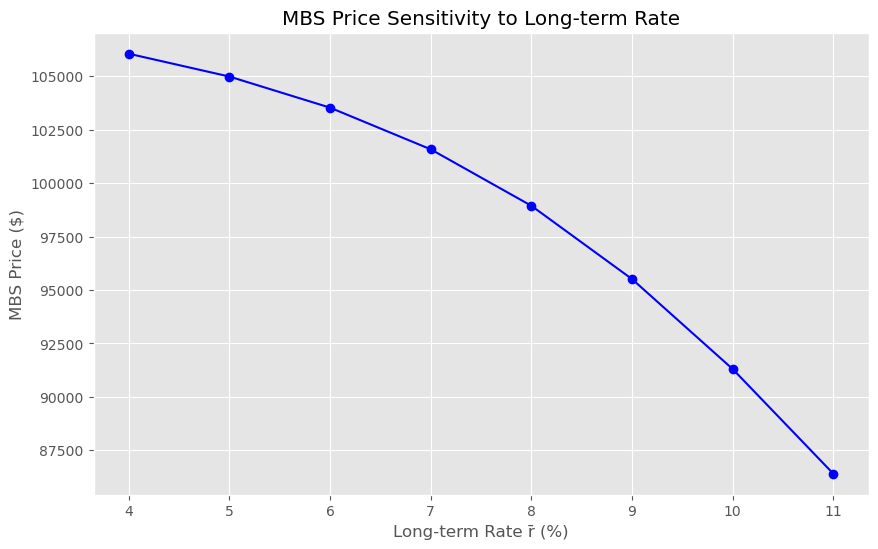


Writeup: MBS prices decrease as the long-term rate increases due to higher discount rates and increased prepayment rates when rates fall below the WAC, reducing the MBS duration.


In [30]:
mbs_price = mbs_pricing()
print(f"Problem 5 Results:")
print(f"(a) MBS Price: ${mbs_price:.2f}")

market_price = 98000
oas = compute_oas(market_price, 0.08, 0.6, 0.12)
print(f"(b) OAS: {oas*100:.2f}%")

io_price, po_price = io_po_pricing()
print(f"(c) IO Price: ${io_price:.2f}")
print(f"    PO Price: ${po_price:.2f}")
print(f"    IO + PO: ${io_price + po_price:.2f}")

r_bar_range = np.arange(0.04, 0.11, 0.01)
mbs_prices_sensitivity = []

for r_bar in r_bar_range:
    price = mbs_pricing(r_bar)
    mbs_prices_sensitivity.append(price)

plt.figure(figsize=(10, 6))
plt.plot(r_bar_range * 100, mbs_prices_sensitivity, 'bo-')
plt.xlabel('Long-term Rate r̄ (%)')
plt.ylabel('MBS Price ($)')
plt.title('MBS Price Sensitivity to Long-term Rate')
plt.grid(True)
plt.show()

print(f"\nWriteup: MBS prices decrease as the long-term rate increases due to higher discount rates and increased prepayment rates when rates fall below the WAC, reducing the MBS duration.")

# Summary of All Results

In [23]:
print("="*80)
print("MGMTMFE 432 - PROJECT 3 COMPLETE RESULTS")
print("="*80)

print("\n1. JUMP-DIFFUSION COLLATERALIZED LOAN DEFAULT OPTION")
print("-"*60)
D_final, Prob_final, Et_final = Proj3_2func(0.2, 5)
print(f"Default Option Value: ${D_final:.4f}")
print(f"Default Probability: {Prob_final:.4f}")
print(f"Expected Exercise Time: {Et_final:.4f} years")

print("\n2. HESTON MODEL DOWN-AND-OUT PUT OPTIONS")
print("-"*60)
P1_final, P2_final, P3_final = heston_down_out_put(100, 1, 0.25)
print(f"P1 (Constant Barrier): ${P1_final:.4f}")
print(f"P2 (Increasing Barrier): ${P2_final:.4f}")
print(f"P3 (Decreasing Barrier): ${P3_final:.4f}")

print("\n3. CIR MODEL BOND AND OPTION PRICING")
print("-"*60)
bond_final = cir_bond_price(0.05, 0.12, 0.92, 0.055, 4)
call_mc_final = cir_call_option_mc(0.05, 0.5, 1, 980, 0.12, 0.92, 0.055)
call_pde_final = cir_call_option_pde(0.05, 0.5, 1, 980, 0.12, 0.92, 0.055)
print(f"Bond Price: ${bond_final:.2f}")
print(f"Call Option (MC): ${call_mc_final:.4f}")
print(f"Call Option (PDE): ${call_pde_final:.4f}")

print("\n4. G2++ MODEL PUT OPTION PRICING")
print("-"*60)
put_mc_final = g2pp_put_option_mc(0.5, 1, 950, 0.7)
put_explicit_final = g2pp_put_option_explicit(0.5, 1, 950, 0.7)
print(f"Put Option (MC): ${put_mc_final:.4f}")
print(f"Put Option (Explicit): ${put_explicit_final:.4f}")

print("\n5. MBS PRICING WITH NUMERIX PREPAYMENT MODEL")
print("-"*60)
mbs_final = mbs_pricing(0.08, 0.6, 0.12, 0.078, 0.08, 100000)
oas_final = compute_oas(98000, 0.08, 0.6, 0.12, 0.078, 0.08, 100000)
io_final, po_final = io_po_pricing(0.08, 0.6, 0.12, 0.078, 0.08, 100000)
print(f"MBS Price: ${mbs_final:.2f}")
print(f"OAS: {oas_final*100:.2f}%")
print(f"IO Price: ${io_final:.2f}")
print(f"PO Price: ${po_final:.2f}")

print("\n" + "="*80)
print("="*80)

MGMTMFE 432 - PROJECT 3 COMPLETE RESULTS

1. JUMP-DIFFUSION COLLATERALIZED LOAN DEFAULT OPTION
------------------------------------------------------------
Default Option Value: $4222.2203
Default Probability: 0.6821
Expected Exercise Time: 1.1296 years

2. HESTON MODEL DOWN-AND-OUT PUT OPTIONS
------------------------------------------------------------
P1 (Constant Barrier): $0.0103
P2 (Increasing Barrier): $0.0023
P3 (Decreasing Barrier): $0.0179

3. CIR MODEL BOND AND OPTION PRICING
------------------------------------------------------------
Bond Price: $189.22
Call Option (MC): $0.3966
Call Option (PDE): $0.0000

4. G2++ MODEL PUT OPTION PRICING
------------------------------------------------------------
Put Option (MC): $6.1491
Put Option (Explicit): $6.1716

5. MBS PRICING WITH NUMERIX PREPAYMENT MODEL
------------------------------------------------------------
MBS Price: $106784.48
OAS: 1.13%
IO Price: $68011.10
PO Price: $38773.38

